## Model Training

In [2]:
import pandas as pd

# load all
students = pd.read_csv("D:/intelligent-erp-analytics/data/anonymisedData/studentInfo.csv")
assessments = pd.read_csv("D:/intelligent-erp-analytics/data/anonymisedData/assessments.csv")
student_assess = pd.read_csv("D:/intelligent-erp-analytics/data/anonymisedData/studentAssessment.csv")

# STEP 1: merge student + studentAssessment
df = students.merge(student_assess, on="id_student")

# STEP 2: merge with assessments (on id_assessment)
df = df.merge(assessments, on="id_assessment")

# STEP 3: clean target
df["final_result"] = df["final_result"].map({
    "Pass": 1,
    "Fail": 0,
    "Distinction": 1,
    "Withdrawn": 0
})

print(df.head())

  code_module_x code_presentation_x  id_student gender               region  \
0           AAA               2013J       11391      M  East Anglian Region   
1           AAA               2013J       11391      M  East Anglian Region   
2           AAA               2013J       11391      M  East Anglian Region   
3           AAA               2013J       11391      M  East Anglian Region   
4           AAA               2013J       11391      M  East Anglian Region   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification  90-100%     55<=                     0              240   
2  HE Qualification  90-100%     55<=                     0              240   
3  HE Qualification  90-100%     55<=                     0              240   
4  HE Qualification  90-100%     55<=                     0              240   

   ... final_result  id_assessment  date_sub

In [3]:
features = df[[
    "num_of_prev_attempts",
    "studied_credits",
    "score",
    "weight"
]]

target = df["final_result"]

In [4]:
student_vle = pd.read_csv(
    "D:/intelligent-erp-analytics/data/anonymisedData/studentVle.csv"
)

engagement = (
    student_vle
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
)

df = df.merge(engagement, on="id_student", how="left")

print(df.head())

  code_module_x code_presentation_x  id_student gender               region  \
0           AAA               2013J       11391      M  East Anglian Region   
1           AAA               2013J       11391      M  East Anglian Region   
2           AAA               2013J       11391      M  East Anglian Region   
3           AAA               2013J       11391      M  East Anglian Region   
4           AAA               2013J       11391      M  East Anglian Region   

  highest_education imd_band age_band  num_of_prev_attempts  studied_credits  \
0  HE Qualification  90-100%     55<=                     0              240   
1  HE Qualification  90-100%     55<=                     0              240   
2  HE Qualification  90-100%     55<=                     0              240   
3  HE Qualification  90-100%     55<=                     0              240   
4  HE Qualification  90-100%     55<=                     0              240   

   ... id_assessment  date_submitted  is_ban

In [5]:
df["sum_click"] = df["sum_click"].fillna(0)

In [6]:
features = df[[
    "num_of_prev_attempts",
    "studied_credits",
    "score",
    "weight",
    "sum_click"
]]

target = df["final_result"]

In [7]:
student_df = df.groupby("id_student").agg({
    "num_of_prev_attempts": "first",
    "studied_credits": "first",
    "score": "mean",          # avg performance
    "weight": "sum",          # total weight attempted
    "sum_click": "first",     # engagement
    "final_result": "first"   # target
}).reset_index()

print(student_df.head())

   id_student  num_of_prev_attempts  studied_credits      score  weight  \
0        6516                     0               60  61.800000   100.0   
1        8462                     0               90  87.000000   180.0   
2       11391                     0              240  82.000000   100.0   
3       23629                     2               60  82.500000    25.0   
4       23698                     0              120  74.444444   200.0   

   sum_click  final_result  
0     2791.0             1  
1      656.0             0  
2      934.0             1  
3      161.0             0  
4      910.0             1  


In [8]:
student_df = df.groupby("id_student").agg({
    "num_of_prev_attempts": "first",
    "studied_credits": "first",
    "score": "mean",          # avg performance
    "weight": "sum",          # total weight attempted
    "sum_click": "first",     # engagement
    "final_result": "first"   # target
}).reset_index()

print(student_df.head())

   id_student  num_of_prev_attempts  studied_credits      score  weight  \
0        6516                     0               60  61.800000   100.0   
1        8462                     0               90  87.000000   180.0   
2       11391                     0              240  82.000000   100.0   
3       23629                     2               60  82.500000    25.0   
4       23698                     0              120  74.444444   200.0   

   sum_click  final_result  
0     2791.0             1  
1      656.0             0  
2      934.0             1  
3      161.0             0  
4      910.0             1  


In [10]:
student_df = df.groupby("id_student").agg({
    "num_of_prev_attempts": "first",
    "studied_credits": "first",
    "score": "mean",
    "weight": "sum",
    "sum_click": "first",
    "final_result": "first"
}).reset_index()

In [11]:
student_df["engagement_per_credit"] = (
    student_df["sum_click"] / student_df["studied_credits"]
)

student_df["performance_index"] = (
    student_df["score"] * student_df["weight"] / 100
)

In [12]:
features = student_df[[
    "num_of_prev_attempts",
    "studied_credits",
    "score",
    "weight",
    "sum_click",
    "engagement_per_credit",
    "performance_index"
]]

target = student_df["final_result"]

In [27]:
print(student_df.columns)

Index(['id_student', 'num_of_prev_attempts', 'studied_credits', 'score',
       'weight', 'sum_click', 'final_result', 'engagement_per_credit',
       'performance_index'],
      dtype='object')


In [14]:
student_df["engagement_per_credit"] = (
    student_df["sum_click"] / (student_df["studied_credits"] + 1)
)

In [19]:
student_df.to_csv(
    "D:/intelligent-erp-analytics/backend/app/ml_models/processed_student_data.csv",
    index=False
)

In [24]:
print(student_df.isnull().sum())

id_student               0
num_of_prev_attempts     0
studied_credits          0
score                    0
weight                   0
sum_click                0
final_result             0
engagement_per_credit    0
performance_index        0
dtype: int64


In [26]:
# fill score first
student_df["score"] = student_df["score"].fillna(student_df["score"].mean())

# recompute everything cleanly
student_df["performance_index"] = (
    student_df["score"] * student_df["weight"] / 100
)

student_df.to_csv(
    "D:/intelligent-erp-analytics/backend/app/ml_models/processed_student_data.csv",
    index=False
)

In [25]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# =========================
# LOAD DATA (your prepared student_df)
# =========================

df = pd.read_csv(
    "D:/intelligent-erp-analytics/backend/app/ml_models/processed_student_data.csv"
)

features = df[[
    "num_of_prev_attempts",
    "studied_credits",
    "score",
    "weight",
    "sum_click",
    "engagement_per_credit",
    "performance_index"
]]

target = df["final_result"]

# =========================
# SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# =========================
# MODELS DICTIONARY
# =========================

models = {
    "logistic": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=100, max_depth=5),
    "svm": SVC(probability=True),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

results = []

# =========================
# TRAIN LOOP
# =========================

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")

    # save model
    joblib.dump(model, f"saved_models/model_{name}.pkl")

    results.append({
        "model": name,
        "accuracy": acc,
        "f1_score": f1
    })

# =========================
# SAVE RESULTS
# =========================

results_df = pd.DataFrame(results)
results_df.to_csv("reports/results.csv", index=False)

print("\nAll models trained and saved")


Training logistic...


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

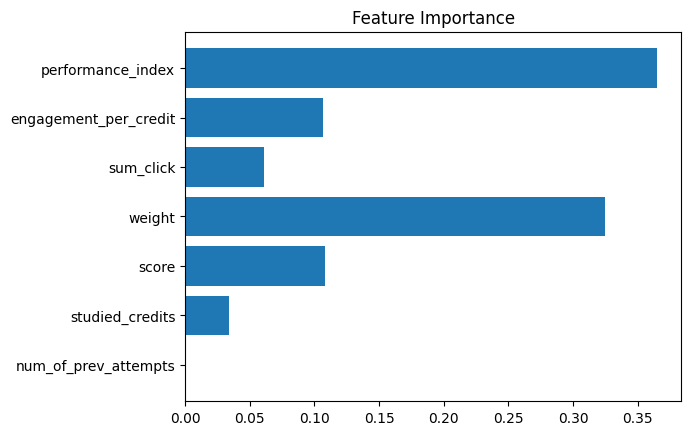

In [17]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.barh(features.columns, importance)
plt.title("Feature Importance")
plt.show()